# Week 9: Gradient Boosting
Include ideas such as gradient boost, learning rate, number of estimators, tree depth, and regularization.

In [1]:
# Data Science Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold,
    RepeatedStratifiedKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    accuracy_score,
    mean_squared_error,
    classification_report
)
from sklearn.pipeline import make_pipeline

# globals
random_state = 42

In [2]:
def split_scale(model_class=None, X=None, y=None, test_size=0.2, random_state=42, **model_params):
    # Error handling
    if model_class is None:
        raise ValueError('Please provide a model class not the instance.')
    if X is None or y is None:
        raise ValueError('You must provide features and target for model building.')

    # Split data into train and test data subsets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
    
    # Scale the features
    model = make_pipeline(
        StandardScaler(),
        model_class(**model_params)
    )

    return X_train, X_test, y_train, y_test, model



def visualize_classification_results(y_test, y_pred, y_proba=None):
    class_names = np.unique(y_test)

    # Set up the plotting grid
    plt.figure(figsize=(16, 4))

    # Plot Confusion Matrix
    plt.subplot(1, 3, 1)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues', colorbar=False, ax=plt.gca())
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

    if y_proba is not None and len(class_names) == 2:
        plt.subplot(1, 3, 2)
        fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
        plt.plot([0, 1], [0, 1], 'r--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend()

        plt.subplot(1, 3, 3)
        precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1])
        plt.plot(recall, precision)
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title('Precision-Recall Curve')

    plt.tight_layout()
    plt.show()



def run_classification_model(model, X_train, X_test, y_train, y_test, n_repeats=5, n_jobs=-1, confusion=False, **model_params):

    # Cross-validation setup
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=n_repeats, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, scoring='accuracy', cv=cv, n_jobs=n_jobs)
    
    # Fit model on full training set
    model.fit(X_train, y_train)
    
    # Predictions
    train_preds = model.predict(X_train)
    y_preds = model.predict(X_test)

    # Check if predict_proba is an attribute
    y_proba = None
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)
    
    # Metrics
    results = {
        "mean_cv_accuracy": np.mean(cv_scores),
        "std_cv_accuracy": np.std(cv_scores),
        "train_accuracy": accuracy_score(y_train, train_preds),
        "test_accuracy": accuracy_score(y_test, y_preds),
    }

    print(f"Mean CV Accuracy: {results['mean_cv_accuracy']:.4f}",
        f"\nStd CV Accuracy: {results['std_cv_accuracy']:.4f}",
        f"\nTrain Accuracy: {results['train_accuracy']:.4f}",
        f"\nTest Accuracy: {results['test_accuracy']:.4f}"
        )

    # Optionally add confusion matrices
    if confusion:
        results["confusion_train"] = confusion_matrix(y_train, train_preds)
        results["confusion_test"] = confusion_matrix(y_test, y_preds)
        visualize_classification_results(y_test, y_preds, y_proba)

    return results


## Dataset 1: Web Page Phishing Detection

In [3]:
# Load cleaned data
cleaned_webpage = pd.read_csv('cleaned_webpage.csv')
cleaned_webpage.head()

,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,nb_eq,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,legitimate
0,37,19,0,3,0,0,0,0,0,0,...,0,1,0,45,0,0,1,1,4,1
1,77,23,1,1,0,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,0
2,126,50,1,4,1,0,1,2,0,3,...,1,0,0,14,4004,5828815,0,1,0,0
3,18,11,0,2,0,0,0,0,0,0,...,1,0,0,62,0,107721,0,0,3,1
4,55,15,0,2,2,0,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,1


In [4]:
# Define X (features) and y (target value)
X = cleaned_webpage.drop(columns=['legitimate'])
X_scaled = StandardScaler().fit_transform(X)

y = cleaned_webpage['legitimate']

In [5]:
GB_params = {'n_estimators': np.arange(30, 340, 40),
            'learning_rate': np.arange(0, 1.1, 0.3),
            'max_depth': np.arange(2, 40, 2),
            'min_samples_split': np.arange(2, 20, 2)
}

In [6]:
model = GradientBoostingClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=GB_params,
    n_iter=20,         
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_scaled, y)

print("\nBest Parameters:", random_search.best_params_)
print("\nBest CV Score:", random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters: {'n_estimators': 310, 'min_samples_split': 10, 'max_depth': 6, 'learning_rate': 0.6}

Best CV Score: 0.9691163604549432


Mean CV Accuracy: 0.9677 
Std CV Accuracy: 0.0033 
Train Accuracy: 1.0000 
Test Accuracy: 0.9703


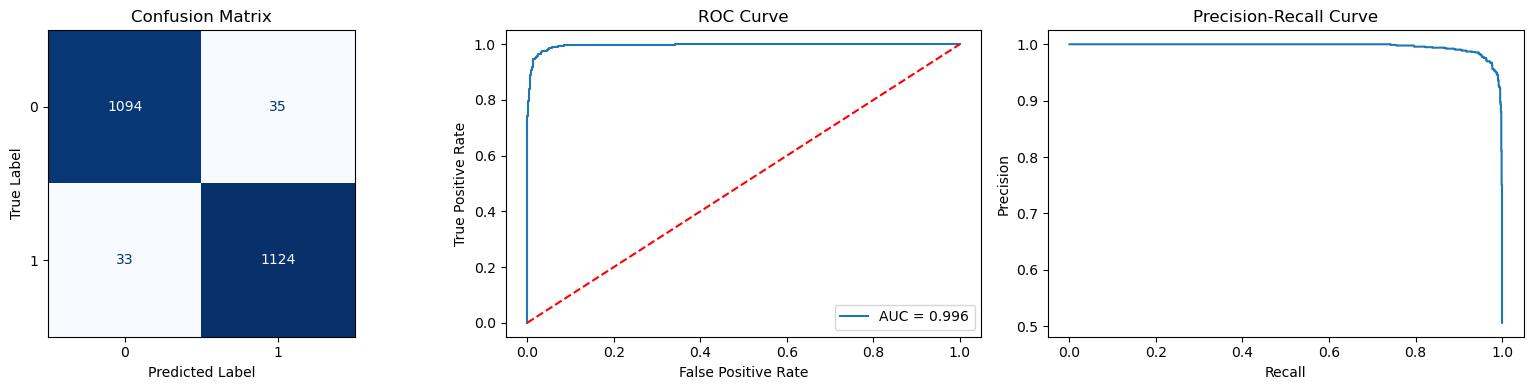

In [7]:
Xa_train, Xa_test, ya_train, ya_test, modela = split_scale(GradientBoostingClassifier, X, y, **random_search.best_params_)
resultsa = run_classification_model(modela, Xa_train, Xa_test, ya_train, ya_test, confusion=True)

## Dataset 2: Phishing Email Detection

In [8]:
# Load cleaned data
cleaned_email = pd.read_csv('cleaned_phishing_email.csv')
cleaned_email.head()

,polarity,subjectivity,unique_words,char_count,word_count,uppercase_ratio,symbol_ratio,kw_urgent,kw_verify,kw_account,kw_click,kw_suspend,kw_update,kw_login,kw_confirm,currency_symbol_count,phone_number_count,Safe Email
0,0.201493,0.514213,110.0,1030.0,230.0,0.000000,0.059223,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0.009375,0.084375,53.0,479.0,91.0,0.000000,0.037578,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,0.091540,0.515783,102.0,1245.0,305.0,0.000000,0.077108,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0.260069,0.690278,73.0,688.0,96.0,0.056686,0.162791,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0
4,0.152579,0.505258,60.0,441.0,91.0,0.000000,0.061224,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [9]:
# Define X (features) and y (target value)
X2 = cleaned_email.drop(columns=['Safe Email'])
X2_scaled = StandardScaler().fit_transform(X2)

y2 = cleaned_email['Safe Email']

In [10]:
model2 = GradientBoostingClassifier(random_state=42)

random_search2 = RandomizedSearchCV(
    estimator=model2,
    param_distributions=GB_params,
    n_iter=20,         
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search2.fit(X2_scaled, y2)

print("\nBest Parameters:", random_search2.best_params_)
print("\nBest CV Score:", random_search2.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters: {'n_estimators': 190, 'min_samples_split': 8, 'max_depth': 30, 'learning_rate': 0.6}

Best CV Score: 0.8540031531588796


Mean CV Accuracy: 0.8491 
Std CV Accuracy: 0.0058 
Train Accuracy: 0.9891 
Test Accuracy: 0.8437


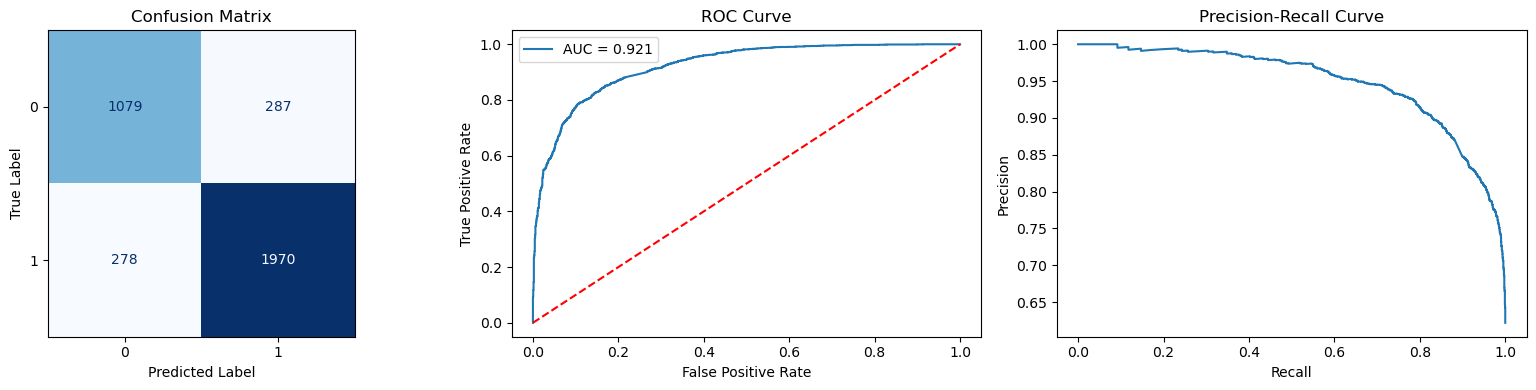

In [11]:
X2a_train, X2a_test, y2a_train, y2a_test, model2a = split_scale(GradientBoostingClassifier, X2, y2, **random_search2.best_params_)
results2a = run_classification_model(model2a, X2a_train, X2a_test, y2a_train, y2a_test, confusion=True)

## Dataset 3: Credit Card Transactions Fraud Detection Dataset

In [12]:
# Load cleaned data
cleaned_credit_card = pd.read_csv('cleaned_ccd.csv')
cleaned_credit_card.head()

,cc_num,merchant,category,amt,gender,city,state,lat,long,city_pop,job,unix_time,merch_lat,merch_long,age,full_name,max_repeats,is_fraud
0,0,0,0,2.86,0,0,0,33.9659,-80.9355,333497,0,1371816865,33.986391,-81.200714,57,0,3,0
1,1,1,0,29.84,1,1,1,40.3207,-110.4360,302,1,1371816873,39.450498,-109.960431,35,1,4,0
2,2,2,1,41.28,1,2,2,40.6729,-73.5365,34496,2,1371816893,40.495810,-74.196111,55,2,4,0
3,3,3,2,60.05,0,3,3,28.5697,-80.8191,54767,3,1371816915,28.812398,-80.883061,38,3,4,0
4,4,4,3,3.19,0,4,4,44.2529,-85.0170,1126,4,1371816917,44.959148,-85.884734,70,4,3,0


In [13]:
# Pull a random subset of the data to use
df_sample = cleaned_credit_card.sample(n=8000, random_state=42)

# Define X (features) and y (target value)
X3 = df_sample.drop(columns=['is_fraud'])
X3_scaled = StandardScaler().fit_transform(X3)

y3 = df_sample['is_fraud']

In [14]:
model3 = GradientBoostingClassifier(random_state=42)

random_search3 = RandomizedSearchCV(
    estimator=model3,
    param_distributions=GB_params,
    n_iter=20,         
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search3.fit(X3_scaled, y3)

print("\nBest Parameters:", random_search3.best_params_)
print("\nBest CV Score:", random_search3.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters: {'n_estimators': 190, 'min_samples_split': 18, 'max_depth': 24, 'learning_rate': 0.0}

Best CV Score: 0.994375


Mean CV Accuracy: 0.9947 
Std CV Accuracy: 0.0003 
Train Accuracy: 0.9947 
Test Accuracy: 0.9931


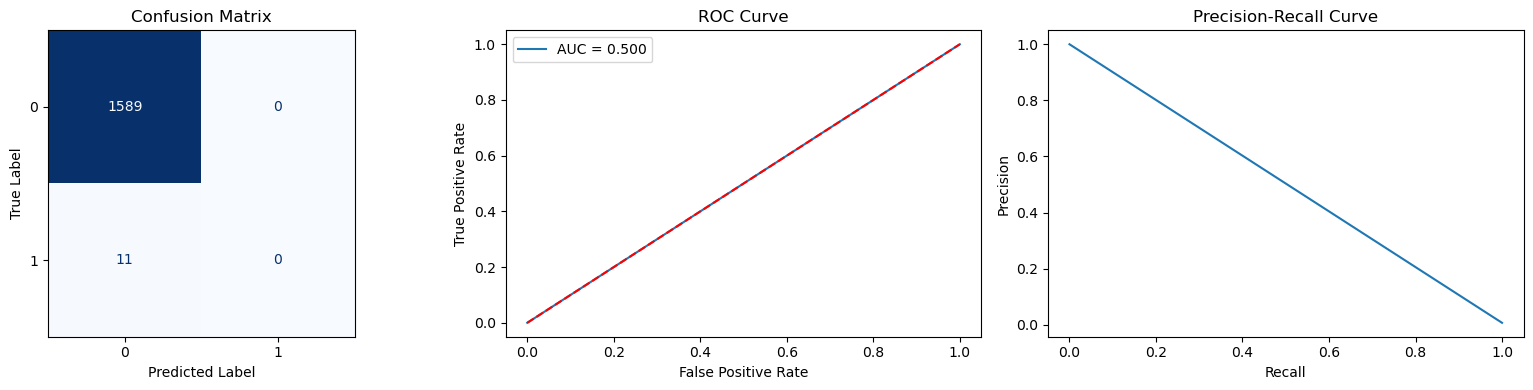

In [15]:
X3a_train, X3a_test, y3a_train, y3a_test, model3a = split_scale(GradientBoostingClassifier, X3, y3, **random_search3.best_params_)
results3a = run_classification_model(model3a, X3a_train, X3a_test, y3a_train, y3a_test, confusion=True)

# Summary

In [19]:
summary = pd.DataFrame({'Dataset': [1, 2, 3], 'Mean CV Accuracy':[0.9677, 0.8491, 0.9947], 'Train Accuracy': [1.000, 0.9891, 0.9947], 'Test Accuracy': [0.9703, 0.8437, 0.9931]})
print('Gradient Boosting Accuracy Scores')
print('-'*60)
print(summary.to_string(index=False))
print('-'*60)

Gradient Boosting Accuracy Scores
------------------------------------------------------------
 Dataset  Mean CV Accuracy  Train Accuracy  Test Accuracy
       1            0.9677          1.0000         0.9703
       2            0.8491          0.9891         0.8437
       3            0.9947          0.9947         0.9931
------------------------------------------------------------


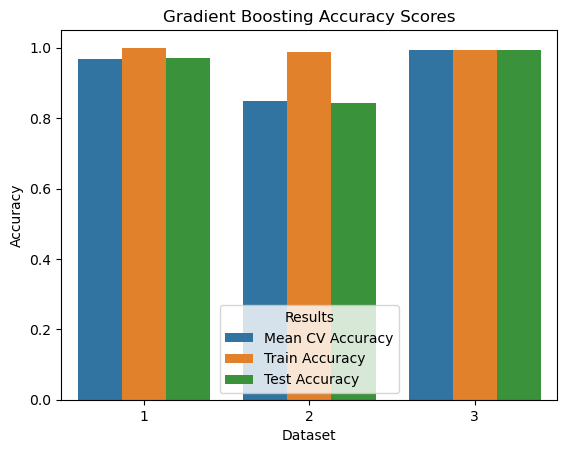

In [20]:
# Create Visualization
summary_melted = summary.melt(id_vars="Dataset", 
                              value_vars=["Mean CV Accuracy", "Train Accuracy", "Test Accuracy"], 
                              var_name="Results", 
                              value_name="Accuracy")

sns.barplot(x='Dataset', y='Accuracy', hue='Results', data=summary_melted)
plt.title("Gradient Boosting Accuracy Scores")
plt.show()